# 2. Dataset Exploration

In [20]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from collections import Counter

## 2.1 Upload and Extract Dataset

The dataset ZIP file is uploaded and extracted to access the image folders for further analysis and preprocessing.

In [21]:
from google.colab import files
import zipfile
import os

# Upload ZIP file
uploaded = files.upload()

# Get uploaded ZIP filename
zip_filename = list(uploaded.keys())[0]

# Extract ZIP
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall('/content/')

print("Dataset extracted successfully!")

Saving dataset.zip to dataset (1).zip
Dataset extracted successfully!


## 2.2 Verify Dataset Structure

The dataset structure is checked to ensure that all image class folders are extracted correctly.

In [22]:
dataset_path = "/content/part_2_cnn_computer_vision/images"

classes = os.listdir(dataset_path)

print("Classes Found:")
print(classes)

Classes Found:
['stain', 'normal', '.DS_Store', 'scratch', 'dent']


## 2.3 Load Valid Class Names

The valid image class folders are identified while excluding unnecessary system files.

In [23]:
# Remove hidden/system files
classes = [cls for cls in classes if not cls.startswith('.')]

print("Valid Classes:")
print(classes)

print("\nNumber of Classes:", len(classes))

Valid Classes:
['stain', 'normal', 'scratch', 'dent']

Number of Classes: 4


## 2.4 Count Images Per Class

The number of images present in each class is calculated to understand the dataset distribution and identify possible class imbalance.

In [24]:
image_count = {}

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    count = len(os.listdir(class_path))

    image_count[class_name] = count

# Create DataFrame
df_counts = pd.DataFrame(
    image_count.items(),
    columns=["Class", "Image Count"]
)

df_counts

,Class,Image Count
0,stain,120
1,normal,120
2,scratch,120
3,dent,120


### Observation

The dataset contains 4 image classes:
- dent
- normal
- scratch
- stain

Each class contains 120 images, resulting in a balanced dataset distribution.

Since all classes contain an equal number of images, the risk of model bias toward a particular class is reduced. A balanced dataset generally helps the CNN model learn features from all categories more effectively and improves overall classification performance.

## 2.5 Display Sample Images

Sample images from each class are visualized to understand the visual differences between categories.

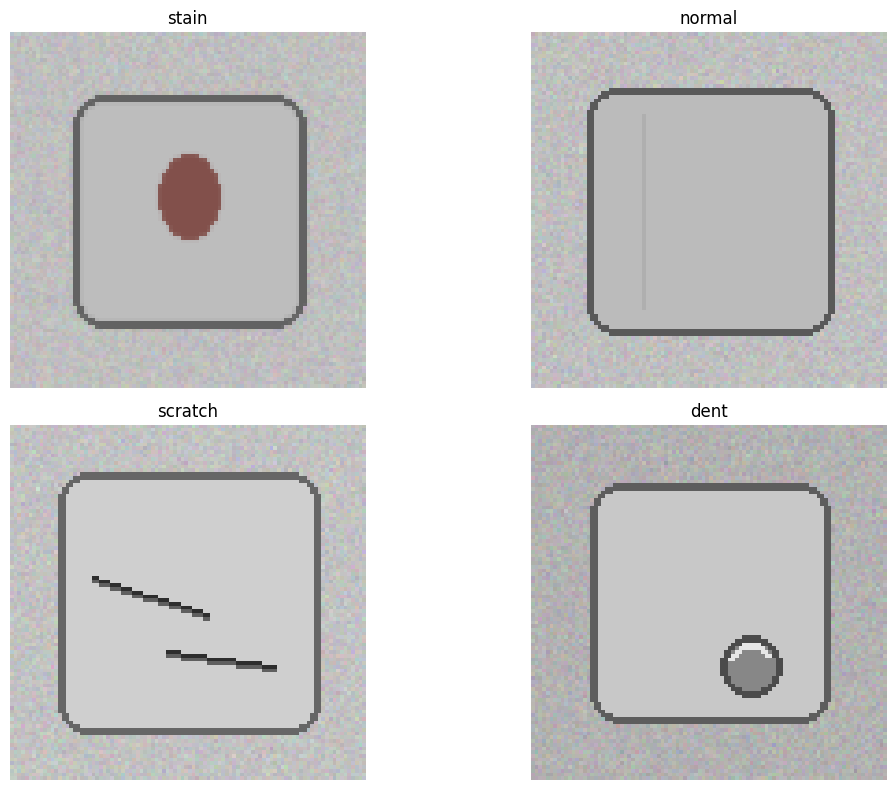

In [25]:
plt.figure(figsize=(12, 8))

for i, class_name in enumerate(classes):

    class_path = os.path.join(dataset_path, class_name)

    image_name = os.listdir(class_path)[0]

    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(2, 2, i + 1)
    plt.imshow(image)
    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

### Observation

The sample images clearly show visual differences between the four classes.

- **stain** images contain visible discoloration or patches on the surface
- **scratch** images contain linear damaged marks
- **dent** images contain circular surface deformation
- **normal** images represent defect-free surfaces

The images have a consistent background and similar object positioning, which can help the CNN model learn important visual patterns more effectively.

Since the defects are visually distinguishable, the dataset is suitable for a multi-class image classification task using Convolutional Neural Networks (CNNs).

## 2.6 Analyze Image Dimensions

The image dimensions are analyzed to understand whether all images have consistent sizes before preprocessing.

In [26]:
image_sizes = []

for class_name in classes:

    class_path = os.path.join(dataset_path, class_name)

    for image_name in os.listdir(class_path):

        image_path = os.path.join(class_path, image_name)

        image = Image.open(image_path)

        image_sizes.append(image.size)

# Display first 10 image sizes
image_sizes[:10]

[(96, 96),
 (96, 96),
 (96, 96),
 (96, 96),
 (96, 96),
 (96, 96),
 (96, 96),
 (96, 96),
 (96, 96),
 (96, 96)]

### Observation

The dataset images have consistent dimensions of 96 × 96 pixels.

Since all images already share the same size, the preprocessing step becomes simpler and more efficient. Consistent image dimensions are important because CNN models require fixed-size inputs for training and prediction.

Although the dataset already contains uniform image sizes, the images will still be normalized before model training to improve learning performance.`

# 3. Image Preprocessing

## 3.1 Import TensorFlow Libraries

TensorFlow and Keras libraries are imported for image preprocessing, data augmentation, and CNN model development.

In [27]:
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

## 3.2 Apply Image Preprocessing and Augmentation

Image preprocessing is performed to prepare the dataset for CNN training.

The preprocessing steps include:
- rescaling pixel values
- validation split
- data augmentation for better generalization

In [28]:
# Training data generator with augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True
)

# Validation data generator
validation_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

## 3.3 Create Training and Validation Datasets

The dataset is divided into training and validation sets using an 80:20 split for model training and evaluation.

In [29]:
train_generator = train_datagen.flow_from_directory(
    dataset_path,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

validation_generator = validation_datagen.flow_from_directory(
    dataset_path,
    target_size=(96, 96),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 384 images belonging to 4 classes.
Found 96 images belonging to 4 classes.


### Observation

The dataset was successfully divided into training and validation sets using an 80:20 split.

Image preprocessing included:
- resizing images to 96 × 96 pixels
- normalizing pixel values to the range 0–1
- applying augmentation techniques such as rotation, zooming, and horizontal flipping

These preprocessing steps help improve model learning, reduce overfitting, and increase the robustness of the CNN model.

# 4. CNN Model Creation

## 4.1 Build CNN Architecture

A Convolutional Neural Network (CNN) model is created for multi-class image classification.

The model includes:
- convolution layers for feature extraction
- ReLU activation functions
- max pooling layers
- flatten layer
- dense layers
- softmax output layer

In [30]:
model = Sequential()

# First Convolution Block
model.add(Conv2D(
    32,
    (3, 3),
    activation='relu',
    input_shape=(96, 96, 3)
))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Second Convolution Block
model.add(Conv2D(
    64,
    (3, 3),
    activation='relu'
))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Third Convolution Block
model.add(Conv2D(
    128,
    (3, 3),
    activation='relu'
))
model.add(MaxPooling2D(pool_size=(2, 2)))

# Flatten Layer
model.add(Flatten())

# Dense Layer
model.add(Dense(128, activation='relu'))

# Dropout Layer
model.add(Dropout(0.5))

# Output Layer
model.add(Dense(4, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 4.2 Model Summary

The CNN model summary is displayed to understand the layer structure, output shapes, and trainable parameters.

In [31]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,292 (6.61 MB)

 Trainable params: 1,732,292 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

### Observation

The CNN architecture contains multiple convolution and pooling layers for feature extraction and dimensionality reduction.

The model structure includes:
- Conv2D layers for detecting image features
- ReLU activation functions for introducing non-linearity
- MaxPooling layers for reducing feature map size
- Flatten layer for converting feature maps into a one-dimensional vector
- Dense layers for classification
- Softmax output layer for multi-class prediction

The final output layer contains 4 neurons, representing the four image classes:
- dent
- normal
- scratch
- stain

## 4.3 Compile CNN Model

The CNN model is compiled using the Adam optimizer, categorical cross-entropy loss function, and accuracy as the evaluation metric.

In [32]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 5. Model Training and Evaluation

## 5.1 Train the CNN Model

The CNN model is trained using the training dataset and evaluated on the validation dataset over multiple epochs.

In [33]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 696ms/step - accuracy: 0.2578 - loss: 1.4238 - val_accuracy: 0.2500 - val_loss: 1.3846
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 782ms/step - accuracy: 0.2969 - loss: 1.3792 - val_accuracy: 0.3438 - val_loss: 1.3464
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 584ms/step - accuracy: 0.4427 - loss: 1.2532 - val_accuracy: 0.6875 - val_loss: 1.0049
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 721ms/step - accuracy: 0.6458 - loss: 0.9063 - val_accuracy: 0.7396 - val_loss: 0.7085
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 596ms/step - accuracy: 0.6797 - loss: 0.6785 - val_accuracy: 0.7812 - val_loss: 0.5301
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 10s 586ms/step - accuracy: 0.7604 - loss: 0.5392 - val_accuracy: 0.7500 - val_loss: 0.4467
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 9s 719ms/step - accuracy: 0.7578 - loss: 0.5506 - val_accuracy: 0.7812 - val_loss: 0.3639
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 667ms/step - accuracy: 0.8229 - loss: 0.4778 - val_accuracy: 

### Observation

The CNN model showed continuous improvement during training.

Key observations:
- training accuracy increased gradually across epochs
- validation accuracy also improved consistently
- validation loss decreased over time

The final model achieved approximately:
- **86.7% training accuracy**
- **91.7% validation accuracy**

These results indicate that the CNN model successfully learned meaningful visual patterns from the dataset and performed effective multi-class image classification.

## 5.2 Plot Accuracy and Loss Curves

Training and validation accuracy/loss curves are plotted to analyze the learning performance of the CNN model across epochs.

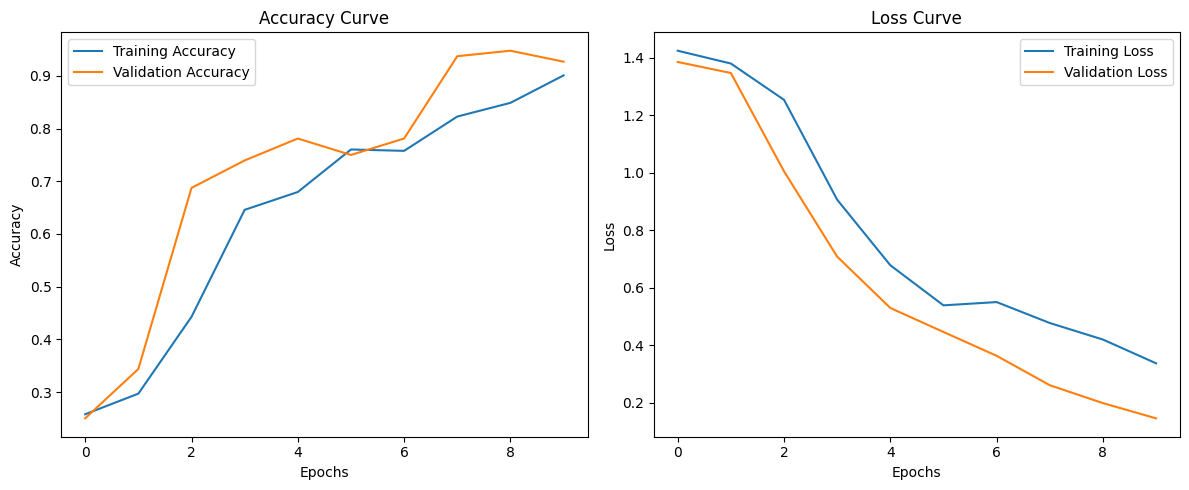

In [34]:
plt.figure(figsize=(12,5))

# Accuracy Plot
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('Accuracy Curve')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Loss Plot
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('Loss Curve')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()

# Save figure
plt.savefig("accuracy_loss_curves.png")

plt.show()

### Observation

The accuracy curve shows that both training and validation accuracy improved consistently during training.

The loss curve shows a steady reduction in both training and validation loss across epochs, indicating effective learning by the CNN model.

The validation accuracy remained high without a significant increase in validation loss, suggesting that the model generalized well and did not suffer from severe overfitting.

## 5.3 Generate Predictions

Predictions are generated on the validation dataset for performance evaluation and confusion matrix analysis.

In [35]:
# Reset validation generator
validation_generator.reset()

# Generate predictions
predictions = model.predict(validation_generator)

# Predicted class indices
predicted_classes = np.argmax(predictions, axis=1)

# True class indices
true_classes = validation_generator.classes

# Class labels
class_labels = list(validation_generator.class_indices.keys())

print("Predictions generated successfully!")

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 157ms/step
Predictions generated successfully!


## 5.4 Confusion Matrix

A confusion matrix is generated to analyze the class-wise prediction performance of the CNN model.

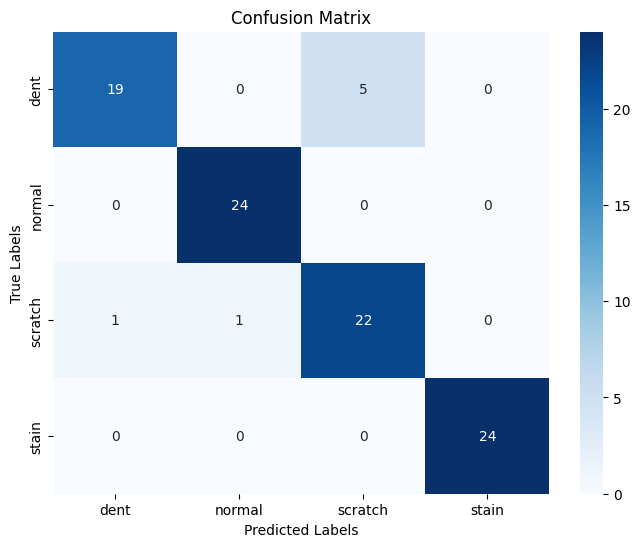

In [36]:
from sklearn.metrics import confusion_matrix

# Generate confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Plot confusion matrix
plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_labels,
    yticklabels=class_labels
)

plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")

# Save figure
plt.savefig("confusion_matrix.png")

plt.show()

### Observation

The confusion matrix shows that the CNN model performed well across all four classes.

Most predictions are concentrated along the diagonal, indicating correct classifications.

Key observations:
- the model achieved excellent classification performance for the **normal** and **stain** classes
- only a few misclassifications occurred between **dent** and **scratch** classes
- the overall prediction performance is strong and consistent

The confusion matrix confirms that the CNN model successfully learned meaningful visual features from the dataset.

## 5.5 Sample Predictions

Sample predictions are displayed to visually evaluate the CNN model’s classification performance on validation images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 376ms/step


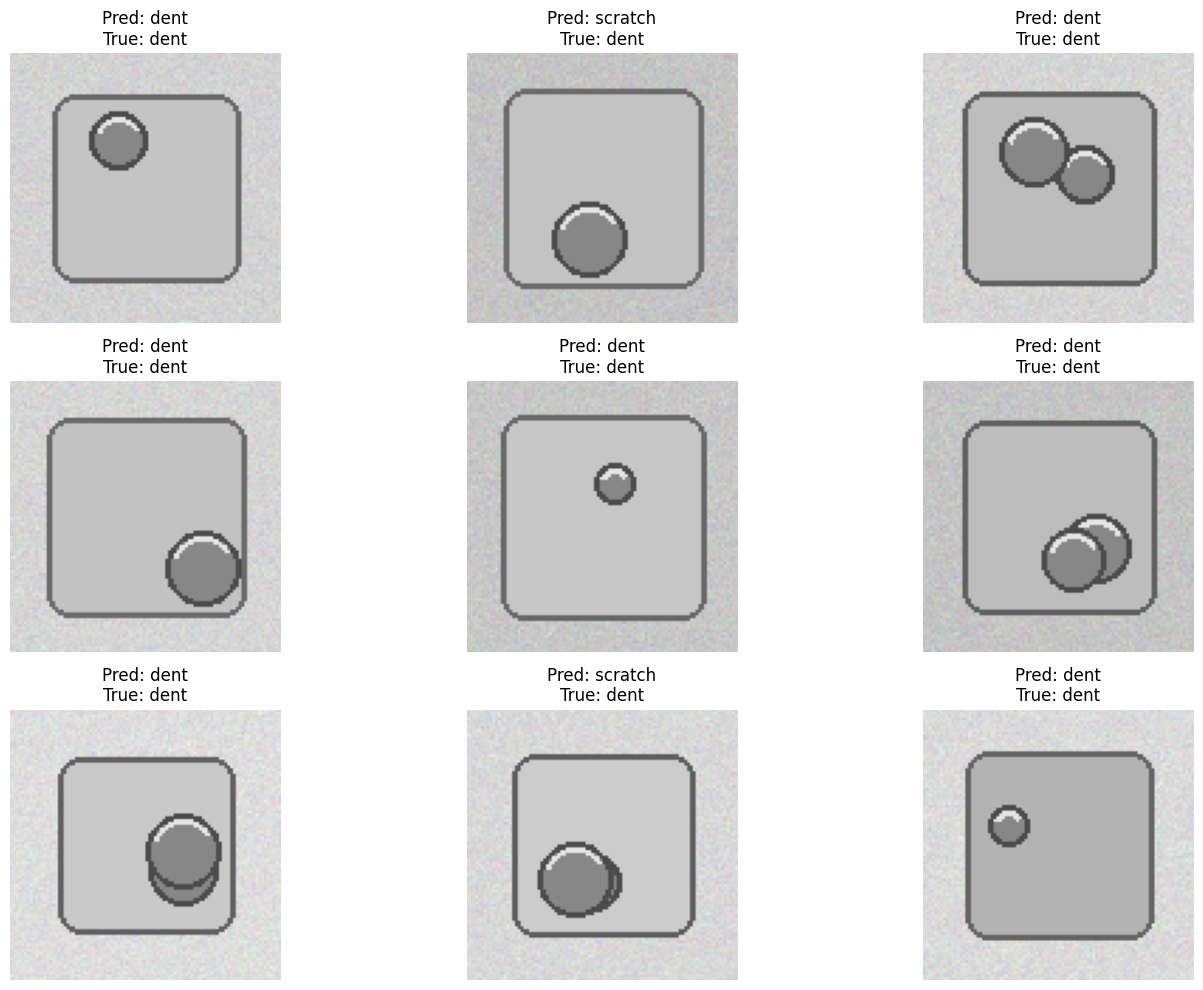

In [37]:
# Get a batch of validation images
images, labels = next(validation_generator)

# Predict classes
predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(labels, axis=1)

# Plot sample predictions
plt.figure(figsize=(15,10))

for i in range(9):

    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    pred_label = class_labels[predicted_classes[i]]
    true_label = class_labels[true_classes[i]]

    plt.title(f"Pred: {pred_label}\nTrue: {true_label}")

    plt.axis("off")

plt.tight_layout()

# Save figure
plt.savefig("prediction_outputs.png")

plt.show()

### Observation

The sample predictions demonstrate that the CNN model can correctly classify most defect categories.

Most images were predicted accurately, indicating that the model successfully learned meaningful visual patterns from the dataset.

A few minor misclassifications occurred between visually similar defect classes such as dent and scratch, which is expected in practical image classification problems.

Overall, the CNN model achieved strong prediction performance on unseen validation images.

# 6. CNN Concept Explanation

## What is Convolution?

Convolution is a mathematical operation used in CNNs to extract important visual features from images such as edges, textures, shapes, and patterns.

A convolution layer applies small filters (kernels) over the input image to detect meaningful features automatically during training.

This helps the CNN learn visual characteristics required for image classification.

## Why is Pooling Used?

Pooling is used to reduce the size of feature maps generated by convolution layers.

Max pooling helps:
- reduce computational complexity
- reduce memory usage
- retain important features
- improve generalization

It also helps the CNN become more robust to small image variations.

## Why is ReLU Commonly Used in CNNs?

ReLU (Rectified Linear Unit) is an activation function that converts all negative values to zero while keeping positive values unchanged.

It is commonly used because:
- it introduces non-linearity
- it improves training speed
- it reduces the vanishing gradient problem
- it helps deep neural networks learn complex patterns effectively

## Why are CNNs Better than Regular Feed-Forward Networks for Image Data?

CNNs are specifically designed for image processing tasks.

Compared to regular feed-forward neural networks, CNNs:
- automatically extract image features
- preserve spatial relationships between pixels
- require fewer parameters
- perform better on visual data

Feed-forward networks treat images as simple numerical vectors, while CNNs can understand important visual structures such as edges, shapes, and textures.

# 7. Business Use Case Mapping

## Manufacturing Industry Use Case

This type of CNN-based computer vision solution can be used in the manufacturing industry for automated surface defect inspection.

Manufacturing companies can use cameras and CNN models to automatically detect defects such as dents, scratches, and stains on products during production.

Benefits of this system include:
- faster quality inspection
- reduced manual effort
- improved product quality
- reduced production errors
- real-time defect detection

Such systems are commonly used in industries such as automobile manufacturing, electronics production, and metal surface inspection.

# 8. Conclusion

In this project, a CNN-based image classification model was developed to classify surface defect images into four categories:
- dent
- normal
- scratch
- stain

The dataset was explored, preprocessed, and used to train a Convolutional Neural Network using TensorFlow/Keras.

The model achieved strong classification performance and successfully learned meaningful visual features from the dataset.

This project demonstrated how CNNs can be effectively applied to real-world computer vision problems such as automated defect detection in manufacturing industries.

In [38]:
import os

os.makedirs("sample_predictions", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Folders created successfully!")

Folders created successfully!


In [39]:
import shutil

# Move prediction image
shutil.move(
    "prediction_outputs.png",
    "sample_predictions/prediction_outputs.png"
)

# Move accuracy/loss graph
shutil.move(
    "accuracy_loss_curves.png",
    "results/accuracy_loss_curves.png"
)

# Move confusion matrix
shutil.move(
    "confusion_matrix.png",
    "results/confusion_matrix.png"
)

print("Files moved successfully!")

Files moved successfully!
